In [ ]:
# @title Függőségek Telepítése
!pip install -qq easyocr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 28.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 908.3/908.3 kB 54.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.2/307.2 kB 28.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 60.4 MB/s eta 0:00:00


In [ ]:
# ⚠️ Adatok nem elérhetőek (Google Drive törölve)
# @title Képek Letöltése
# !gdown -qq 1p6ikCp62HoxE0BSHwoO8zhNJC1RbxbzC
# !unzip -qq hegyek.zip -d hegyek
# !rm -rf hegyek.zip


In [ ]:
import os
import easyocr
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets

plt.style.use('ggplot')

In [ ]:
reader = easyocr.Reader(['en'])

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

In [ ]:
class HegyekDataset(Dataset):
    def __init__(self, directory, transform=None):
        self.directory = directory
        self.transform = transform
        self.images = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith(('jpeg', 'png', 'jpg'))]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image_path = self.images[idx]
        image = datasets.folder.default_loader(image_path)

        if self.transform:
            image = self.transform(image)

        return image

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomVerticalFlip(p=1.0),
    transforms.RandomHorizontalFlip(p=1.0),
])

dataset = HegyekDataset(directory='./hegyek', transform=transform)
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

Text: N, Probability: 0.9999090453803525


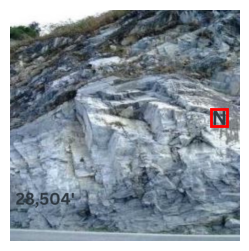

Text: 28,504', Probability: 0.9998687465380818


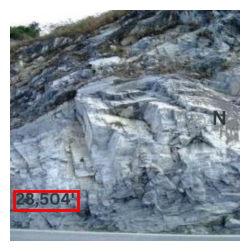

Text: E19, Probability: 0.897943065917156


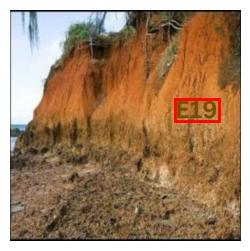

Text: N 47, Probability: 0.9282808739957155


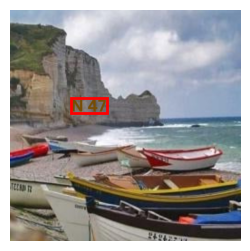

Text: E, Probability: 0.9936880845837095


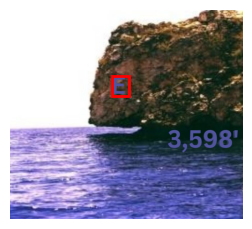

Text: 3,598', Probability: 0.9419512173845873


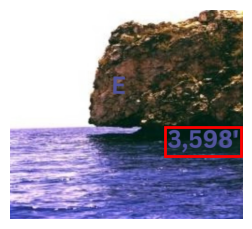

In [ ]:
for i, images in enumerate(dataloader):
    numpy_image = images.squeeze().permute(1, 2, 0).numpy()
    numpy_image = (numpy_image * 255).astype(np.uint8)

    res = reader.readtext(numpy_image)

    for (bbox, text, prob) in res:
        if prob > 0.8:
            print(f'Text: {text}, Probability: {prob}')
            fig, ax = plt.subplots(figsize=(3, 3))
            ax.imshow(numpy_image)
            top_left = bbox[0]
            bottom_right = bbox[2]
            width = bottom_right[0] - top_left[0]
            height = bottom_right[1] - top_left[1]
            rect = patches.Rectangle(top_left, width, height, linewidth=2, edgecolor='r', facecolor='none')
            ax.add_patch(rect)
            plt.axis('off')
            plt.show()

In [ ]:
print('Final Coordinate is:\n N 47° 28,504\' \n E 19° 3,598\'')

Final Coordinate is:
 N 47° 28,504' 
 E 19° 3,598'
